# Notebook: Quadcopter Path Following

In [37]:
import sys
from pathlib import Path
 
cwd  = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
 
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import Math, display, Video, HTML
 
from src.simulation.video_sim import VideoSim
from src.utils.config import load_config
from src.utils.plotting import set_style, FigureManager
from src.utils.animations import quadcopter_topdown, to_html5_video_with_progress
from src.control.cascade_controller import QuadState, QuadReference, CascadeController
from src.control.certified_cascade_controller import CertifiedCascadeController
from src.control.path_following_controller import CirclePath, PathFollowingController
from src.symbolic.quadcopter_path_following import (
    derive_path_following,
    compare_trajectory_vs_path_following,
)
 
set_style()

r"""
## Path Following vs Trajectory Tracking
 
### Trajectory Tracking (previous notebook)
 
The reference is **time-parameterised**:
$$p_d(t) = [R\cos(\omega t),\; R\sin(\omega t),\; z_d]^\top$$
 
The reference moves at constant speed $R\omega$ regardless of where the vehicle
is. If the vehicle starts far away, it must simultaneously converge to the path
*and* chase a reference that is moving away.  This produces aggressive transients
when initial conditions are far from the trajectory.
 
### Path Following (this notebook)
 
The reference is **path-parameterised** by a virtual coordinate $\gamma \in \mathbb{R}$:
$$p_d(\gamma) = [R\cos\gamma,\; R\sin\gamma,\; z_d]^\top$$
 
The key addition is a *dynamic law* for $\gamma$:
$$\dot{\gamma} = v_d + k_\gamma\,\hat{\mathbf{t}}(\gamma)^\top \mathbf{e}_p$$
 
where $\hat{\mathbf{t}}(\gamma)$ is the unit tangent to the path and
$\mathbf{e}_p = p - p_d(\gamma)$ is the position error.
 
**Interpretation of the $\gamma$ law:**
- $\hat{\mathbf{t}}^\top \mathbf{e}_p > 0$: vehicle is *ahead* of virtual target → advance $\gamma$ faster
- $\hat{\mathbf{t}}^\top \mathbf{e}_p < 0$: vehicle is *behind* virtual target → slow $\gamma$ down
- $\hat{\mathbf{t}}^\top \mathbf{e}_p \approx 0$: vehicle is mostly off the path laterally → $\dot{\gamma} \approx v_d$
 
The velocity command passed to the cascade controller is:
$$\mathbf{v}_\text{cmd} = \underbrace{\frac{\partial p_d}{\partial\gamma}\dot{\gamma}}_{\text{feedforward}} - K \mathbf{e}_p$$
 
The result: the virtual target *adapts its speed* to stay near the vehicle,
eliminating the "chasing" behaviour and giving smooth transients from any
initial condition.
"""

In [38]:
pf   = derive_path_following()
comp = compare_trajectory_vs_path_following()
 
display(Math(r"\textbf{Path geometry — circle}"))
display(Math(r"p_d(\gamma) = " + sp.latex(pf["p_d"])))
display(Math(r"\frac{\partial p_d}{\partial\gamma} = " + sp.latex(pf["dp_d"])))
display(Math(r"\hat{\mathbf{t}}(\gamma) = " + sp.latex(pf["t_hat"])))
display(Math(r"\psi_d(\gamma) = " + sp.latex(pf["psi_d"])
            + r"\quad\Rightarrow\quad \dot{\psi}_d = \dot{\gamma}"))
 
display(Math(r"\textbf{Virtual target dynamics}"))
display(Math(r"\dot{\gamma} = " + sp.latex(pf["gamma_dot"])))
display(Math(r"e_s = \hat{\mathbf{t}}^\top\mathbf{e}_p = " + sp.latex(pf["e_s"])
            + r"\quad\text{(along-track error)}"))
display(Math(r"e_n = \hat{\mathbf{n}}^\top\mathbf{e}_p = " + sp.latex(pf["e_n"])
            + r"\quad\text{(cross-track error)}"))
 
display(Math(r"\textbf{Velocity command}"))
display(Math(r"\mathbf{v}_\text{cmd} = " + sp.latex(pf["v_cmd"])))
 
display(Math(r"\textbf{Error dynamics}"))
display(Math(r"\dot{\mathbf{e}}_p = \mathbf{v}_\text{cmd} - \frac{\partial p_d}{\partial\gamma}\dot{\gamma} = "
            + sp.latex(pf["e_p_dot"])))
 
display(Math(r"\textbf{Lyapunov analysis}"))
display(Math(r"V = " + sp.latex(pf["V"])))
display(Math(r"\dot{V} = " + sp.latex(pf["V_dot"]) + r" < 0\quad\forall\,\mathbf{e}_p\neq\mathbf{0}"))
display(Math(r"\dot{\gamma}\big|_{\mathbf{e}_p=\mathbf{0}} = "
            + sp.latex(pf["gamma_dot_at_zero"])
            + r" = v_d\quad\text{(desired path speed recovered)}"))
display(Math(r"\boxed{\mathbf{e}_p(t)\to\mathbf{0},\quad\dot{\gamma}(t)\to v_d\quad\textbf{(GAS)}}"))
 
display(Math(r"\textbf{Comparison: trajectory tracking vs path following}"))
display(Math(r"\dot{\gamma}_\text{TT} = " + sp.latex(comp["gamma_TT"])
            + r"\quad\text{(fixed, ignores vehicle position)}"))
display(Math(r"\dot{\gamma}_\text{PF} = " + sp.latex(comp["gamma_dot_PF"])
            + r"\quad\text{(adapts to vehicle position)}"))
display(Math(r"\dot{\gamma}_\text{PF} - v_d = " + sp.latex(comp["gamma_dot_diff"])
            + r"\quad\text{(the correction term)}"))
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [39]:
pf_config_path = str(ROOT / "config/quadcopter_path_following_circle.yaml")
pf_cfg         = load_config(pf_config_path)
fm_pf          = FigureManager(pf_cfg, base_dir=ROOT)
 
# trajectory tracking config for comparison
tt_config_path = str(ROOT / "config/quadcopter_certified_circle.yaml")
tt_cfg         = load_config(tt_config_path)

In [40]:
r"""
## Simulation
 
`QuadcopterPathFollowingSim` integrates $\gamma$ as an additional state.
At each step it:
1. Queries `PathFollowingController.step()` to get the current QuadReference
2. Passes the reference to `CertifiedCascadeController` (inner loop)
3. Logs both vehicle state and $\gamma$, $\dot{\gamma}$
 
The inner loop is identical to the certified notebook.
"""
 
class QuadcopterPathFollowingSim(VideoSim):
 
    def __init__(self, config_path):
        super().__init__(config_path)
 
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model requires a free root joint.")
 
        # initial state
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0
 
        # certified cascade inner loop
        self._ctrl = CertifiedCascadeController.from_model(pf_cfg, self.model)
 
        # path and path-following outer loop
        traj = pf_cfg.get("trajectory", {})
        path = CirclePath(
            R   = traj.get("radius",   3.0),
            z_d = traj.get("z_height", 3.0),
        )
        self._pfc = PathFollowingController.from_config(pf_cfg, path)
 
        # initialise γ to the closest point on the circle
        self._pfc.reset(self.data.qpos[:3].copy())
 
        cam = pf_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    def _capture_frame(self):
        self._camera.lookat[:]  = self.data.qpos[:3]
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    def _loop_step(self, t: float, step: int):
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
 
        # ── path following outer loop ──────────────────────────────────────
        dt  = self.model.opt.timestep
        ref, gamma, gamma_dot = self._pfc.step(state.pos, dt)
 
        # ── certified cascade inner loop ──────────────────────────────────
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
 
        # ── log ───────────────────────────────────────────────────────────
        qw, qx, qy, qz = state.quat
        e_p = state.pos - ref.pos      # position error w.r.t. virtual target
 
        # along-track and cross-track errors
        t_hat = self._pfc.path.unit_tangent(gamma)
        n_hat = np.array([-np.cos(gamma), -np.sin(gamma), 0.0])
        e_s   = float(t_hat @ e_p)
        e_n   = float(n_hat @ e_p)
 
        self.logger.log({
            # vehicle state
            "x":    float(state.pos[0]),
            "y":    float(state.pos[1]),
            "z":    float(state.pos[2]),
            "roll":  float(np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))),
            "pitch": float(np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))),
            "yaw":   float(np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))),
            # virtual target
            "xd":       float(ref.pos[0]),
            "yd":       float(ref.pos[1]),
            "zd":       float(ref.pos[2]),
            "gamma":    float(gamma),
            "gamma_dot": float(gamma_dot),
            # errors
            "ex":   float(e_p[0]),
            "ey":   float(e_p[1]),
            "ez":   float(e_p[2]),
            "e_s":  e_s,   # along-track
            "e_n":  e_n,   # cross-track
            "e_norm": float(np.linalg.norm(e_p)),
            **ctrl_log,
        })
 

In [41]:
pf_sim = QuadcopterPathFollowingSim(pf_config_path)
pf_sim.run()
df_pf = pf_sim.to_dataframe()
df_pf.tail()
 

Simulation: 100%|██████████| 30000/30000 [00:13<00:00, 2196.37step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_path_following_circle.mp4


,x,y,z,roll,pitch,yaw,xd,yd,zd,gamma,...,tau_y,tau_z,f1,f2,f3,f4,gyro_x,gyro_y,gyro_z,t
29995,-4.160236,2.680215,0.024791,3.141593,1.266950e-19,-1.083510,-2.798189,-1.08173,3.0,3.510479,...,-0.060298,0.403300,0.0,4.0,4.0,0.0,-1.415744e-22,-2.326426e-22,0.000000e+00,59.990
29996,-4.160236,2.680215,0.024791,3.141593,1.393174e-19,-1.083527,-2.798189,-1.08173,3.0,3.510479,...,-0.060282,0.403236,0.0,4.0,4.0,0.0,-1.290878e-22,-2.154075e-22,-4.176195e-53,59.992
29997,-4.160236,2.680215,0.024791,3.141593,1.512499e-19,-1.083544,-2.798189,-1.08173,3.0,3.510479,...,-0.060267,0.403172,0.0,4.0,4.0,0.0,-1.210904e-22,-2.099172e-22,0.000000e+00,59.994
29998,-4.160236,2.680215,0.024791,3.141593,1.639230e-19,-1.083560,-2.798189,-1.08173,3.0,3.510479,...,-0.060252,0.403109,0.0,4.0,4.0,0.0,-1.518977e-22,-2.238166e-22,4.176195e-53,59.996
29999,-4.160236,2.680215,0.024791,3.141593,1.790934e-19,-1.083577,-2.798189,-1.08173,3.0,3.510479,...,-0.060236,0.403045,0.0,4.0,4.0,0.0,-1.700010e-22,-2.185258e-22,-4.176195e-53,59.998


In [42]:
# Re-use QuadcopterCertifiedSim from the previous notebook (same initial condition).
 
class QuadcopterTrajectoryTrackingSim(VideoSim):
    """Trajectory tracking sim — identical initial condition as path following."""
 
    def __init__(self, config_path):
        super().__init__(config_path)
        self.data.qpos[:3]  = [0.0, 0.0, 0.5]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]
        self.data.qvel[:]   = 0.0
        self._ctrl = CertifiedCascadeController.from_model(tt_cfg, self.model)
        traj = tt_cfg.get("trajectory", {})
        self.R     = traj.get("radius",   3.0)
        self.omega = traj.get("omega",    0.5)
        self.z_d   = traj.get("z_height", 3.0)
        cam = tt_cfg.get("camera", {})
        self._cam_lookat    = np.array(cam.get("lookat",    [0.0, 0.0, 2.0]))
        self._cam_distance  = float(cam.get("distance",  12.0))
        self._cam_elevation = float(cam.get("elevation", -30.0))
        self._cam_azimuth   = float(cam.get("azimuth",   45.0))
 
    def _capture_frame(self):
        self._camera.lookat[:]  = self.data.qpos[:3]
        self._camera.distance   = self._cam_distance
        self._camera.elevation  = self._cam_elevation
        self._camera.azimuth    = self._cam_azimuth
        self._renderer.update_scene(self.data, camera=self._camera)
        self._frames.append(self._renderer.render())
 
    def _loop_step(self, t: float, step: int):
        state = QuadState(
            pos    = self.data.qpos[:3].copy(),
            quat   = self.data.qpos[3:7].copy(),
            vel    = self.data.qvel[:3].copy(),
            angvel = self.data.qvel[3:6].copy(),
        )
        xd  =  self.R * np.cos(self.omega * t)
        yd  =  self.R * np.sin(self.omega * t)
        vxd = -self.R * self.omega * np.sin(self.omega * t)
        vyd =  self.R * self.omega * np.cos(self.omega * t)
        ref = QuadReference(
            pos      = np.array([xd, yd, self.z_d]),
            vel      = np.array([vxd, vyd, 0.0]),
            yaw      = self.omega * t + np.pi / 2.0,
            yaw_rate = self.omega,
        )
        forces, ctrl_log = self._ctrl.compute(state, ref)
        self.data.ctrl[:] = forces
 
        e_p = state.pos - ref.pos
        self.logger.log({
            "x": float(state.pos[0]), "y": float(state.pos[1]), "z": float(state.pos[2]),
            "xd": float(ref.pos[0]),  "yd": float(ref.pos[1]),  "zd": float(ref.pos[2]),
            "ex": float(e_p[0]),      "ey": float(e_p[1]),      "ez": float(e_p[2]),
            "e_norm": float(np.linalg.norm(e_p)),
            **ctrl_log,
        })
 

In [43]:
tt_sim = QuadcopterTrajectoryTrackingSim(tt_config_path)
tt_sim.run()
df_tt = tt_sim.to_dataframe()
 

Simulation: 100%|██████████| 30000/30000 [00:12<00:00, 2370.32step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_certified_circle.mp4


  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/3d_comparison.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/3d_comparison.png


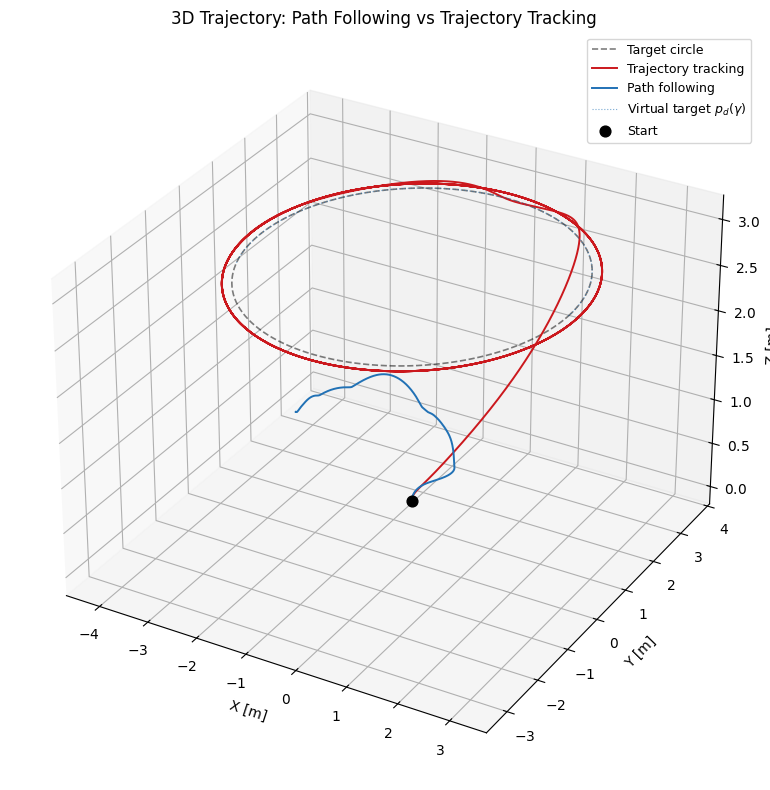

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/3d_comparison.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/3d_comparison.png')]

In [44]:

fig_3d = plt.figure(figsize=(9, 8))
ax = fig_3d.add_subplot(111, projection="3d")
 
# reference circle
theta = np.linspace(0, 2*np.pi, 300)
R_c, z_c = pf_cfg["trajectory"]["radius"], pf_cfg["trajectory"]["z_height"]
ax.plot(R_c*np.cos(theta), R_c*np.sin(theta), z_c,
        "k--", linewidth=1.2, alpha=0.5, label="Target circle")
 
# trajectory tracking
ax.plot(df_tt["x"], df_tt["y"], df_tt["z"],
        color="#cb181d", linewidth=1.4, label="Trajectory tracking")
 
# path following
ax.plot(df_pf["x"], df_pf["y"], df_pf["z"],
        color="#2171b5", linewidth=1.4, label="Path following")
 
# virtual target on path
ax.plot(df_pf["xd"], df_pf["yd"], df_pf["zd"],
        color="#2171b5", linewidth=0.8, linestyle=":",
        alpha=0.6, label=r"Virtual target $p_d(\gamma)$")
 
# start marker
ax.scatter([0], [0], [0.5], color="black", s=60, zorder=5, label="Start")
 
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title("3D Trajectory: Path Following vs Trajectory Tracking")
ax.legend(fontsize=9)
fig_3d.tight_layout()
fm_pf.save_and_show(fig_3d, "3d_comparison")
 

  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/transient_comparison.pdf
  ↳ saved /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/transient_comparison.png


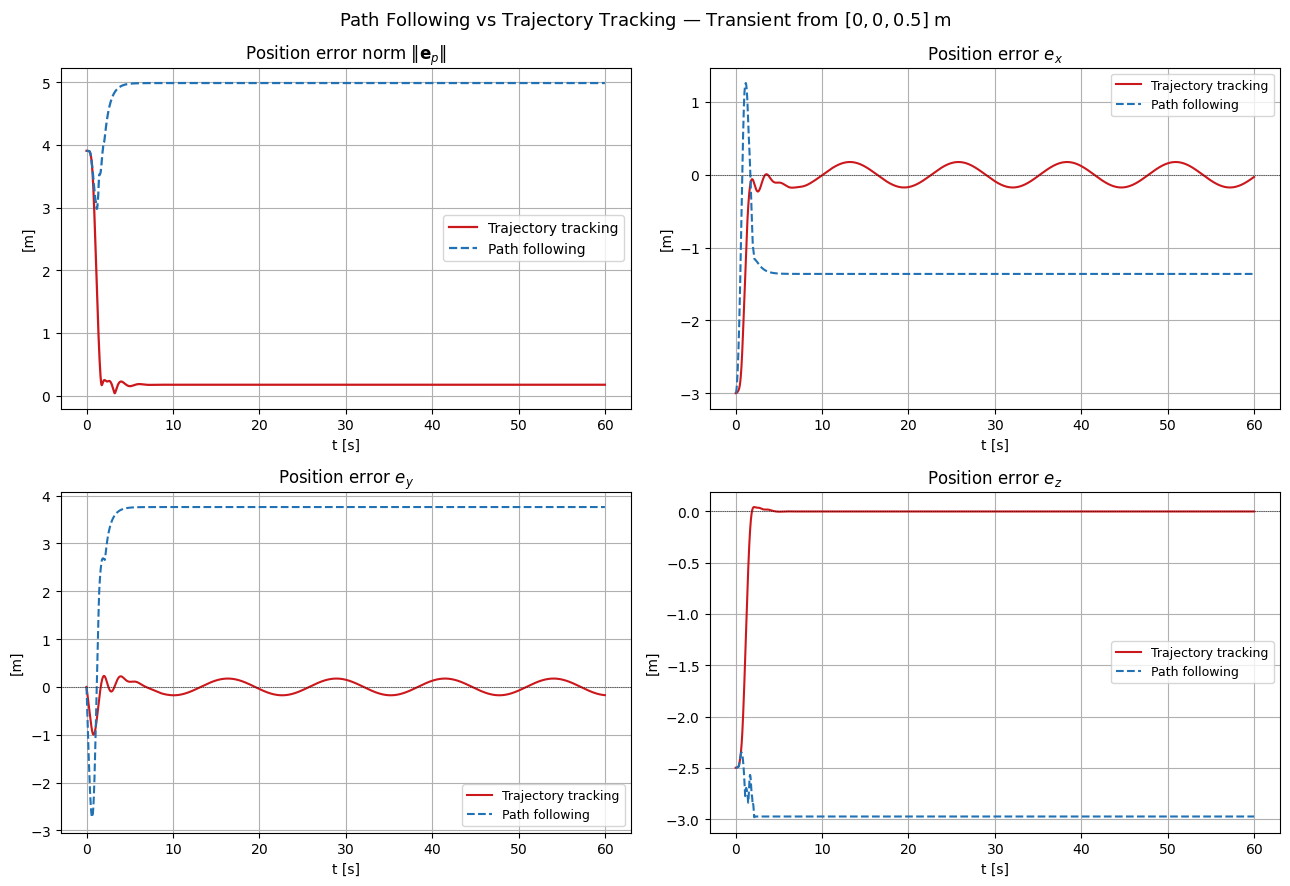

[PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/transient_comparison.pdf'),
 PosixPath('/Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/figures/quadcopter_path_following_circle/transient_comparison.png')]

In [45]:
r"""
## Transient Comparison
 
The key plot: ‖e_p(t)‖ for both controllers from the same initial condition.
Path following should show a monotonically decreasing error (GAS proof holds).
Trajectory tracking shows a more oscillatory transient.
"""
 
fig_trans, axs = plt.subplots(2, 2, figsize=(13, 9))
# ── error norm ────────────────────────────────────────────────────────────────
axs[0, 0].plot(df_tt["t"], df_tt["e_norm"],
               color="#cb181d", linewidth=1.6, label="Trajectory tracking")
axs[0, 0].plot(df_pf["t"], df_pf["e_norm"],
               color="#2171b5", linewidth=1.6, linestyle="--", label="Path following")
axs[0, 0].set_title(r"Position error norm $\|\mathbf{e}_p\|$")
axs[0, 0].set_xlabel("t [s]"); axs[0, 0].set_ylabel("[m]")
axs[0, 0].legend(); axs[0, 0].grid()
 
# ── individual errors ─────────────────────────────────────────────────────────
for ax, col, lbl in zip(
    [axs[0, 1], axs[1, 0], axs[1, 1]],
    ["ex", "ey", "ez"],
    [r"$e_x$", r"$e_y$", r"$e_z$"],
):
    ax.plot(df_tt["t"], df_tt[col], color="#cb181d",
            linewidth=1.5, label="Trajectory tracking")
    ax.plot(df_pf["t"], df_pf[col], color="#2171b5",
            linewidth=1.5, linestyle="--", label="Path following")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"Position error {lbl}")
    ax.set_xlabel("t [s]"); ax.set_ylabel("[m]")
    ax.legend(fontsize=9); ax.grid()
 
fig_trans.suptitle(
    "Path Following vs Trajectory Tracking — Transient from $[0, 0, 0.5]$ m",
    fontsize=13)
fig_trans.tight_layout()
fm_pf.save_and_show(fig_trans, "transient_comparison")
 
 